# 问题四 结果分析与可视化

读取 `scripts/run_q4_optimization.py` 输出的 CSV，绘制导通概率与成本的可视化，并输出最优解表格。

In [1]:
import pandas as pd
import os

# 获取项目根目录（notebook 在 notebooks/ 下）
repo_root = os.path.dirname(os.getcwd())

# 读取精细扫描结果
fine_csv_path = os.path.join(repo_root, 'results/outputs/q4_fine_results.csv')
df = pd.read_csv(fine_csv_path)

# 筛选满足约束的点，找成本最小的
feasible = df[df['p_hat'] >= 0.9]
best = feasible.loc[feasible['cost'].idxmin()]

print("=== 问题四最优解 ===")
print(f"fA = {best['fA']:.6f} ({best['fA']*100:.4f}%)")
print(f"fB = {best['fB']:.6f} ({best['fB']*100:.4f}%)")
print(f"N_A = {int(best['N_A'])} 根")
print(f"N_B = {int(best['N_B'])} 个")
print(f"p_hat = {best['p_hat']:.4f} ({best['p_hat']*100:.2f}%)")
print(f"95% CI = [{best['ci_low']:.4f}, {best['ci_high']:.4f}]")
print(f"成本 = {best['cost']:.4f} 元")

=== 问题四最优解 ===
fA = 0.000121 (0.0121%)
fB = 0.000000 (0.0000%)
N_A = 9 根
N_B = 0 个
p_hat = 0.9315 (93.15%)
95% CI = [0.9196, 0.9418]
成本 = 0.1266 元


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# plotting: Chinese font
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
from pathlib import Path
import os

# === 获取项目根目录（Notebook 在 notebooks/ 下） ===
repo_root = Path(os.getcwd()).parent

out_dir = repo_root / 'results/outputs'
coarse_csv = out_dir / 'q4_coarse_results.csv'
fine_csv = out_dir / 'q4_fine_results.csv'
final_csv = out_dir / 'q4_best_answer.csv'

# 读取数据（如果文件不存在则为空 DataFrame）
df_coarse = pd.read_csv(coarse_csv) if coarse_csv.exists() else pd.DataFrame()
df_fine = pd.read_csv(fine_csv) if fine_csv.exists() else pd.DataFrame()

# 合并数据
if not df_coarse.empty or not df_fine.empty:
    df_all = pd.concat([df_coarse, df_fine], ignore_index=True)
else:
    df_all = pd.DataFrame()

print(f'粗扫数据: {len(df_coarse)} 行')
print(f'精细扫描数据: {len(df_fine)} 行')
print(f'合并后总数据: {len(df_all)} 行')

# === 提取最优解 ===
if final_csv.exists():
    # 如果 best_answer 已生成，直接读取
    best = pd.read_csv(final_csv)
    print("\n=== 从 q4_best_answer.csv 读取最优解 ===")
    print(best)
elif not df_all.empty:
    # 否则从合并数据中提取
    feasible = df_all[df_all['p_hat'] >= 0.9]
    if not feasible.empty:
        best = feasible.loc[feasible['cost'].idxmin()]
        print("\n=== 从精细扫描/粗扫数据提取最优解 ===")
        print(f"fA = {best['fA']:.6f} ({best['fA']*100:.4f}%)")
        print(f"fB = {best['fB']:.6f} ({best['fB']*100:.4f}%)")
        print(f"N_A = {int(best['N_A'])} 根")
        print(f"N_B = {int(best['N_B'])} 个")
        print(f"p_hat = {best['p_hat']:.4f} ({best['p_hat']*100:.2f}%)")
        print(f"95% CI = [{best['ci_low']:.4f}, {best['ci_high']:.4f}]")
        print(f"成本 = {best['cost']:.4f} 元")
    else:
        best = None
        print("\n⚠️ 数据中没有满足 p_hat >= 0.9 的点")
else:
    best = None
    print("\n⚠️ 没有数据，请先运行问题四脚本")

粗扫数据: 3845 行
精细扫描数据: 9831 行
合并后总数据: 13676 行

=== 从精细扫描/粗扫数据提取最优解 ===
fA = 0.000121 (0.0121%)
fB = 0.000000 (0.0000%)
N_A = 9 根
N_B = 0 个
p_hat = 0.9315 (93.15%)
95% CI = [0.9196, 0.9418]
成本 = 0.1266 元


Saved q4_heatmap.png
Saved q4_cost_scatter.png

=== 最优解 ===
fA = 0.000121 (0.0121%)
fB = 0.000000 (0.0000%)
N_A = 9 根
N_B = 0 个
p_hat = 0.9315 (93.15%)
95% CI = [0.9196, 0.9418]
成本 = 0.1266 元


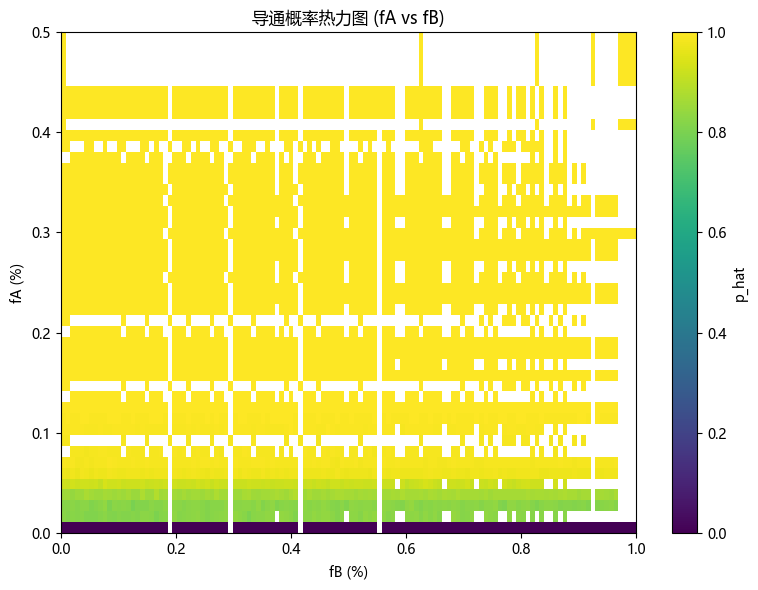

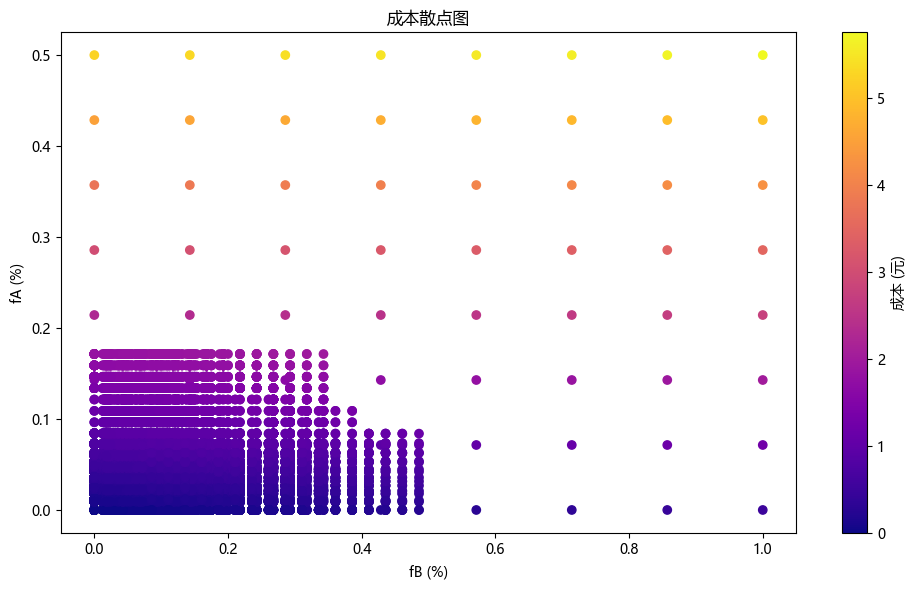

In [ ]:
# === 绘图：导通概率热力图 + 成本散点图 ===
if not df_all.empty:
    # --- 热力图：导通概率 ---
    pivot_p = df_all.pivot_table(index='fA', columns='fB', values='p_hat', aggfunc='mean')
    plt.figure(figsize=(8, 6))
    plt.imshow(pivot_p.values, origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1,
               extent=[pivot_p.columns.min()*100, pivot_p.columns.max()*100,
                       pivot_p.index.min()*100, pivot_p.index.max()*100])
    plt.colorbar(label='p_hat')
    plt.xlabel('fB (%)')
    plt.ylabel('fA (%)')
    plt.title('导通概率热力图 (fA vs fB)')
    plt.tight_layout()
    plt.savefig(out_dir / 'q4_heatmap.png', dpi=200)
    print('Saved q4_heatmap.png')

    # --- 成本散点图 ---
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_all['fB']*100, df_all['fA']*100, c=df_all['cost'], cmap='plasma')
    plt.colorbar(sc, label='成本 (元)')
    plt.xlabel('fB (%)')
    plt.ylabel('fA (%)')
    plt.title('成本散点图')
    plt.tight_layout()
    plt.savefig(out_dir / 'q4_cost_scatter.png', dpi=200)
    print('Saved q4_cost_scatter.png')

    # --- 打印最优解 ---
    if best is not None:
        if isinstance(best, pd.Series):
            print("\n=== 最优解 ===")
            print(f"fA = {best['fA']:.6f} ({best['fA']*100:.4f}%)")
            print(f"fB = {best['fB']:.6f} ({best['fB']*100:.4f}%)")
            print(f"N_A = {int(best['N_A'])} 根")
            print(f"N_B = {int(best['N_B'])} 个")
            print(f"p_hat = {best['p_hat']:.4f} ({best['p_hat']*100:.2f}%)")
            print(f"95% CI = [{best['ci_low']:.4f}, {best['ci_high']:.4f}]")
            print(f"成本 = {best['cost']:.4f} 元")
        else:
            print(best)
    else:
        print('未找到满足 p_hat >= 0.9 的最优解')
else:
    print('没有结果文件，请先运行 scripts/run_q4_optimization.py 生成 CSV。')

In [7]:
# analysis/q4_analysis.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from pathlib import Path
import time
import os, sys

# 确保 repo 根在 sys.path（与 notebooks/01 一致的处理）
repo_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if repo_root not in sys.path:
    sys.path.append(repo_root)

results_dir = Path("results/outputs")
coarse_csv = results_dir / "q4_coarse_results.csv"
fine_csv = results_dir / "q4_fine_results.csv"
final_csv = results_dir / "q4_best_answer.csv"

# --- 1) load CSVs (if missing, create empty DataFrame) ---
df_coarse = pd.read_csv(coarse_csv) if coarse_csv.exists() else pd.DataFrame()
df_fine = pd.read_csv(fine_csv) if fine_csv.exists() else pd.DataFrame()
df_all = pd.concat([df_coarse, df_fine], ignore_index=True) if (not df_coarse.empty or not df_fine.empty) else pd.DataFrame()

print(f"Loaded coarse rows={len(df_coarse)}, fine rows={len(df_fine)}, total rows={len(df_all)}")

# --- 2) select best point and save q4_best_answer.csv ---
def select_best_and_save(df_all, threshold=0.90, out_path=final_csv):
    if df_all.empty:
        print("No data to select from.")
        return None
    # ensure numeric types
    for c in ['p_hat','ci_low','cost','fA','fB']:
        if c in df_all.columns:
            df_all[c] = pd.to_numeric(df_all[c], errors='coerce')
    # prefer p_hat >= threshold
    feasible = df_all[df_all['p_hat'] >= threshold].copy()
    source = None
    if feasible.empty:
        # fallback to ci_low >= threshold
        feasible = df_all[df_all['ci_low'] >= threshold].copy()
        if feasible.empty:
            print("No feasible point found with p_hat >= threshold or ci_low >= threshold.")
            # return the point with highest p_hat / cost ratio as suggestion
            df_all['score'] = df_all['p_hat'] / (df_all['cost'] + 1e-12)
            cand = df_all.sort_values('score', ascending=False).iloc[0]
            cand = cand.to_dict()
            cand['found'] = False
            cand['note'] = 'No feasible point; suggested best by p_hat/cost ratio'
            pd.DataFrame([cand]).to_csv(out_path, index=False)
            print("Saved suggested best to", out_path)
            return cand
        else:
            source = 'ci_low'
    else:
        source = 'p_hat'
    # pick minimal cost among feasible
    best = feasible.loc[feasible['cost'].idxmin()]
    best = best.to_dict()
    best['found'] = True
    best['selection_source'] = source
    best['timestamp'] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
    pd.DataFrame([best]).to_csv(out_path, index=False)
    print("Saved best answer to", out_path)
    return best

best = select_best_and_save(df_all, threshold=0.9, out_path=final_csv)
print("Best:", best)

# --- 3) plotting helpers ---
plot_dir = results_dir
plot_dir.mkdir(parents=True, exist_ok=True)

def plot_probability_heatmap(df_all, out_png=plot_dir/"q4_pheatmap.png"):
    if df_all.empty:
        print("No data for heatmap")
        return
    # pivot if grid; otherwise use triangulation
    x = df_all['fB'].values * 100.0  # percent
    y = df_all['fA'].values * 100.0
    z = df_all['p_hat'].values
    # triangulate and contourf
    triang = tri.Triangulation(x, y)
    plt.figure(figsize=(7,6))
    cf = plt.tricontourf(triang, z, levels=20, cmap='viridis', vmin=0.0, vmax=1.0)
    plt.colorbar(cf, label='p_hat')
    plt.scatter(x, y, c='k', s=6, alpha=0.4)
    plt.xlabel('fB (%)'); plt.ylabel('fA (%)')
    plt.title('导通概率热力图 p_hat (fA vs fB)')
    if best is not None and best.get('found', False):
        plt.plot(best['fB']*100.0, best['fA']*100.0, 'r*', markersize=14, label='best')
        plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print("Saved", out_png)

def plot_cost_contours_with_feasible(df_all, out_png=plot_dir/"q4_cost_contour_feasible.png"):
    if df_all.empty:
        print("No data for cost contour")
        return
    x = df_all['fB'].values * 100.0
    y = df_all['fA'].values * 100.0
    z = df_all['cost'].values
    p = df_all['p_hat'].values
    triang = tri.Triangulation(x, y)
    plt.figure(figsize=(7,6))
    # cost contour
    levels = 12
    cs = plt.tricontourf(triang, z, levels=levels, cmap='plasma')
    plt.colorbar(cs, label='cost (元)')
    # feasible mask contour: plot boundary where p >= 0.9
    mask = p >= 0.9
    if mask.any():
        # draw feasible points in black circles
        plt.scatter(x[mask], y[mask], facecolors='none', edgecolors='k', label='feasible (p>=0.9)')
    # mark best
    if best is not None and best.get('found', False):
        plt.plot(best['fB']*100.0, best['fA']*100.0, 'r*', markersize=14, label='best')
    plt.xlabel('fB (%)'); plt.ylabel('fA (%)')
    plt.title('成本等高线 (可行域标注)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print("Saved", out_png)

def plot_slices(df_all, fixed_fB_list=None, out_png=plot_dir/"q4_slices.png"):
    if df_all.empty:
        print("No data for slices")
        return
    if fixed_fB_list is None:
        # pick a few representative fB values (min, median, max)
        fB_vals = np.unique(np.round(df_all['fB'].values, 8))
        if len(fB_vals) > 5:
            fixed_fB_list = [fB_vals[0], fB_vals[len(fB_vals)//2], fB_vals[-1]]
        else:
            fixed_fB_list = fB_vals
    plt.figure(figsize=(8,5))
    for fB in fixed_fB_list:
        # select rows with fB approximately equal
        sel = df_all[np.isclose(df_all['fB'], fB, atol=1e-12)]
        if sel.empty:
            # broader tolerance
            sel = df_all[np.isclose(df_all['fB'], fB, atol=1e-4)]
        if sel.empty:
            continue
        sel = sel.sort_values('fA')
        plt.plot(sel['fA']*100.0, sel['p_hat'], marker='o', label=f"fB={fB*100:.3f}%")
    plt.axhline(0.9, color='r', linestyle='--', label='threshold=0.9')
    plt.xlabel('fA (%)'); plt.ylabel('p_hat')
    plt.title('固定 fB 的 p_hat 随 fA 变化')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print("Saved", out_png)

def plot_pareto(df_all, out_png=plot_dir/"q4_pareto.png"):
    if df_all.empty:
        return
    df = df_all.copy()
    plt.figure(figsize=(6,5))
    plt.scatter(df['p_hat'], df['cost'], c='C0', alpha=0.6)
    plt.xlabel('p_hat')
    plt.ylabel('cost (元)')
    plt.title('Pareto plot: cost vs p_hat')
    # highlight feasible
    feas = df[df['p_hat']>=0.9]
    if not feas.empty:
        plt.scatter(feas['p_hat'], feas['cost'], c='red', label='feasible (p>=0.9)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print("Saved", out_png)

# run plotting
plot_probability_heatmap(df_all)
plot_cost_contours_with_feasible(df_all)
plot_slices(df_all)
plot_pareto(df_all)

# --- 4) sample microstructure visualization (optional) ---
# This draws a single trial (cyl centers and sphere centers) for a chosen (fA,fB),
# and colors particles that connect left-right (if any).
from src.monte_carlo import sample_random_cylinders, sample_random_spheres
from src.truncation import split_cylinder_by_box, split_sphere_by_box
from src.connectivity import build_connectivity

def plot_sample_structure(fA, fB, seed=0, out_png=plot_dir/"q4_sample_structure.png"):
    N_A = int(round(fA * (L**3) / ((np.pi * (r_A**2) * h_A))))
    N_B = int(round(fB * (L**3) / ((4.0/3.0)*np.pi*(r_B**3))))
    rng = np.random.default_rng(seed)
    cyls = sample_random_cylinders(N_A, L, r_A, h_A, start_id=0, rng=rng)
    sphs = sample_random_spheres(N_B, L, r_B, start_id=N_A, rng=rng)
    particles = []
    for c in cyls:
        particles.extend(split_cylinder_by_box(c, L))
    for s in sphs:
        particles.extend(split_sphere_by_box(s, L))
    connected, uf = build_connectivity(particles, L, thresh)
    # plot centers in 3D scatter (x,y) colored by type
    import matplotlib.pyplot as plt
    xs=[]; ys=[]; cs=[]
    for p in particles:
        if hasattr(p, 'center'):
            cen = p.center()
        elif hasattr(p, 'c'):
            cen = p.c
        else:
            continue
        xs.append(cen[0])
        ys.append(cen[1])
        cs.append('C1' if isinstance(p, type(cyls[0])) else 'C2')
    plt.figure(figsize=(5,5))
    plt.scatter(xs, ys, s=8, c=cs, alpha=0.7)
    plt.title(f"Sample microstructure (fA={fA:.6g}, fB={fB:.6g})")
    plt.xlabel('x (nm)'); plt.ylabel('y (nm)')
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print("Saved sample structure to", out_png)

# if you want a sample structure, call with chosen best
if best is not None and best.get('found', False):
    try:
        plot_sample_structure(best['fA'], best['fB'], seed=20260812)
    except Exception as e:
        print("Sample structure plotting failed:", e)

print("All done.")

Loaded coarse rows=0, fine rows=0, total rows=0
No data to select from.
Best: None
No data for heatmap
No data for cost contour
No data for slices
All done.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path('results/outputs')
coarse_csv = out_dir / 'q4_coarse_results.csv'
fine_csv = out_dir / 'q4_fine_results.csv'
final_csv = out_dir / 'q4_best_answer.csv'

df_coarse = pd.read_csv(coarse_csv) if coarse_csv.exists() else pd.DataFrame()
df_fine = pd.read_csv(fine_csv) if fine_csv.exists() else pd.DataFrame()
df_all = pd.concat([df_coarse, df_fine], ignore_index=True) if not df_coarse.empty or not df_fine.empty else pd.DataFrame()
best = pd.read_csv(final_csv) if final_csv.exists() else None
print('coarse rows:', len(df_coarse), 'fine rows:', len(df_fine))

In [ ]:
if not df_all.empty:
    # pivot to grid for heatmap (requires unique fA,fB grid)
    pivot_p = df_all.pivot_table(index='fA', columns='fB', values='p_hat', aggfunc='mean')
    plt.figure(figsize=(8,6))
    plt.imshow(pivot_p.values, origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1,
               extent=[pivot_p.columns.min()*100, pivot_p.columns.max()*100, pivot_p.index.min()*100, pivot_p.index.max()*100])
    plt.colorbar(label='p_hat')
    plt.xlabel('fB (%)')
    plt.ylabel('fA (%)')
    plt.title('导通概率热力图 (fA vs fB)')
    plt.tight_layout()
    plt.savefig(out_dir / 'q4_pheatmap.png', dpi=200)
    print('Saved q4_pheatmap.png')

    # cost contour: sample points
    plt.figure(figsize=(8,6))
    sc = plt.scatter(df_all['fB']*100, df_all['fA']*100, c=df_all['cost'], cmap='plasma')
    plt.colorbar(sc, label='cost (元)')
    plt.xlabel('fB (%)')
    plt.ylabel('fA (%)')
    plt.title('成本散点图')
    plt.tight_layout()
    plt.savefig(out_dir / 'q4_cost_scatter.png', dpi=200)
    print('Saved q4_cost_scatter.png')

    # print best
    if best is not None and not best.empty:
        display(best)
    else:
        print('No best file found.')
else:
    print('没有结果文件，请先运行 scripts/run_q4_optimization.py 生成 CSV。')